# Metropolis Monte Carlo: Lennard-Jones System



### Dependency Management and Setup
This cell ensures that all required Python packages are installed for running the Monte Carlo simulation. It checks for dependencies and installs any missing ones, helping students avoid environment issues. Always run this cell first before proceeding with the simulation code.

In [3]:
# BOOTSTRAP CELL: Run this to ensure all dependencies are installed
import sys
import subprocess

def install(packages):
    """Installs packages and streams the output to the console for visibility."""
    print(f"Starting installation of: {', '.join(packages)}...")
    process = subprocess.Popen(
        [sys.executable, "-m", "pip", "install", *packages],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )
    
    # Stream the output line by line
    for line in process.stdout:
        print(line, end='')
    
    process.wait()
    if process.returncode == 0:
        print("\n✅ Installation successful!")
    else:
        print(f"\n❌ Installation failed with return code {process.returncode}")

# List of required packages
required_packages = ["numpy", "matplotlib", "numba", "ipykernel","ovito"]

try:
    import numpy
    import matplotlib
    import numba
    import ipykernel
    import ovito
    print("✅ All dependencies (Numba, NumPy, Matplotlib, IPyKernel, Ovito) are already installed!")
except ImportError:
    print("⚠️ Missing dependencies detected.")
    install(required_packages)
    print("🛑 IMPORTANT: Please restart your kernel (Kernel -> Restart) now!")

✅ All dependencies (Numba, NumPy, Matplotlib, IPyKernel, Ovito) are already installed!


## 2. Implement the Lennard-Jones Potential

In this exercise, you will implement the functions required to calculate the interaction between two particles using the **Lennard-Jones (LJ)** potential.

### The Physics
The potential energy $u(r_\mathrm{sq})$ between two particles at distance $r=\sqrt{r_\mathrm{sq}}$ is given by:

$$u_{\mathrm{LJ}}(r_\mathrm{sq}) = 4\varepsilon \left[ \left( \frac{\sigma^2}{r_\mathrm{sq}} \right)^6 - \left(\frac{\sigma^2}{r_\mathrm{sq}} \right)^3 \right]$$

where $\varepsilon$ is the depth of the potential well and $\sigma$ is the distance at which the potential crosses zero.


### Lennard-Jones Potential Function
This cell implements the Lennard-Jones potential, which models the interaction between pairs of particles. Understanding this function is crucial, as it forms the basis for calculating energies in the Monte Carlo simulation. The potential describes both repulsive and attractive forces, and is widely used in molecular simulations.

In [5]:
import numpy as np
from numba import njit
import matplotlib.pyplot as plt

@njit
def compute_lj_potential(r_sq, epsilon=1.0, sigma=1.0):
    """
    Calculate the Lennard-Jones potential energy between two particles.

    Args:
        r_sq (float): Squared distance between two particles.
        epsilon (float): Depth of the potential well (energy scale).
        sigma (float): Distance at which the potential crosses zero (length scale).

    Returns:
        float: Lennard-Jones potential energy u_LJ(r).

    Notes:
        Implements u_LJ(r_sq) = 4*epsilon * [(sigma^2/r_{sq})^6 - (sigma^2/r_{sq})^3].
        Efficiently pre-calculates (sigma^2/r_{sq})^3 for performance.
    """
    sigma_over_r_2 = sigma*sigma / r_sq  # (sigma/r)^2
    sigma_over_r_6 = sigma_over_r_2 * sigma_over_r_2 * sigma_over_r_2  # (sigma/r)^6
    u_pot = 4.0 * epsilon * sigma_over_r_6 * (sigma_over_r_6 - 1.0)
    return u_pot

## 4. Initialization of a Particle System

Let's consider a system of $N$ particles in a simulation box.

We will initialize the particles on a **simple cubic lattice** to avoid overlapping positions (which would cause infinite forces). Then, we assign them random velocities drawn from a normal distribution, which will determine the initial kinetic energy (temperature) of the system.

In the code block below, a basic loop structure is implemented. **Your task** is to specify the particle positions on the cubic lattice.


### Initializing Particle Positions
This cell initializes the positions of all particles in the simulation box. By placing particles on a cubic lattice, we avoid overlaps and ensure a physically reasonable starting configuration. Proper initialization is essential for accurate Monte Carlo sampling and for avoiding infinite energies due to close contacts.

In [6]:
@njit
def initialize_positions(num_particles, L):
    """
    Initialize particle positions on a simple cubic lattice within a cubic simulation box.

    Ensures reasonable separations to avoid singularities in the Lennard-Jones potential.

    Args:
        num_particles (int): Number of particles to initialize.
        L (float): Length of the cubic simulation box.

    Returns:
        ndarray: Array of shape (num_particles, 3) containing initial positions.
    """
    pos = np.empty((num_particles, 3))
    num_1d = int(np.ceil(num_particles**(1/3)))  # Particles per side for cubic lattice
    spacing = L / num_1d
    count = 0
    for i in range(num_1d):
        for j in range(num_1d):
            for k in range(num_1d):
                if count < num_particles:
                    pos[count, 0] = (i + 0.5) * spacing
                    pos[count, 1] = (j + 0.5) * spacing
                    pos[count, 2] = (k + 0.5) * spacing
                    count += 1
                else:
                    break
            if count >= num_particles:
                break
        if count >= num_particles:
            break           
    return pos

### Periodic Boundary Conditions
This cell defines functions for handling periodic boundary conditions. The minimum image convention and box folding ensure that particles interact correctly across the boundaries of the simulation box, mimicking an infinite system. These are fundamental for realistic molecular simulations.

In [7]:
@njit
def min_image(r_vec, L):
    """
    Apply the minimum image convention to a displacement vector for periodic boundary conditions.

    Shifts the displacement vector to the range [-L/2, L/2) by accounting for periodic boundaries.

    Args:
        r_vec (ndarray): Displacement vector between two particles, shape (3,).
        L (float): Box length.

    Returns:
        ndarray: Minimum image displacement vector, shape (3,).
    """
    r_vec -= L * np.floor(r_vec / L + 0.5)
    return r_vec

@njit
def fold_in_box(pos, L):
    """
    Wrap particle positions back into the periodic box [0, L).

    Args:
        pos (ndarray): Particle positions, shape (num_particles, 3).
        L (float): Box length.

    Returns:
        ndarray: Wrapped positions, shape (num_particles, 3).
    """
    pos -= L * np.floor(pos / L)
    return pos

### Trajectory Output for Analysis
This cell provides a function to write particle positions to a file in LAMMPS dump format. Saving the trajectory allows for later analysis and visualization, such as computing the radial distribution function or viewing the system in OVITO.

In [8]:
def write_dump(filename, step, pos, L, mode='a'):
    """
    Write particle positions to a LAMMPS-format dump file for trajectory analysis.

    Args:
        filename (str): Output file path.
        step (int): Current timestep number.
        pos (ndarray): Particle positions, shape (num_particles, 3).
        L (float): Box length.
        mode (str): File open mode ('w' to overwrite, 'a' to append).

    Returns:
        None
    """
    num_particles = pos.shape[0]
    with open(filename, mode) as f:
        f.write("ITEM: TIMESTEP\n")
        f.write(f"{step}\n")
        f.write("ITEM: NUMBER OF ATOMS\n")
        f.write(f"{num_particles}\n")
        f.write("ITEM: BOX BOUNDS pp pp pp\n")
        f.write(f"0.0 {L}\n0.0 {L}\n0.0 {L}\n")
        f.write("ITEM: ATOMS id type x y z\n")
        for i in range(num_particles):
            f.write(f"{i+1} 1 {pos[i,0]} {pos[i,1]} {pos[i,2]}\n")

### Energy Calculation in Monte Carlo
This cell calculates the total potential energy for a particle, considering interactions with all other particles and applying periodic boundary conditions and a cutoff. Accurate energy calculation is essential for the Metropolis acceptance criterion in Monte Carlo simulations.

In [9]:
@njit
def compute_energy(i, r, pos, L, epsilon=1.0, sigma=1.0, r_c=2.5):
    """
    Compute the total Lennard-Jones potential energy for a particle with periodic boundary conditions and cutoff.

    Args:
        i (int): Index of the particle for which to compute energy.
        r (ndarray): Position vector of particle i.
        pos (ndarray): Array of shape (num_particles, 3) containing particle positions.
        L (float): Box length.
        epsilon (float): Depth of the potential well.
        sigma (float): Length scale of the interaction.
        r_c (float): Cutoff distance. If not used, all pairs are considered.

    Returns:
        float: Total potential energy for particle i.
    """
    num_particles = pos.shape[0]
    forces = np.zeros_like(pos)  # Initialize forces to zero
    u_pot = 0.0  # Accumulator for potential energy
    r_c_sq = r_c * r_c  # Square of cutoff distance for efficiency
    # Double loop over all unique pairs (i, j) with i < j
    for j in range(num_particles):
        if j == i:
            continue  # Skip self-interaction
        r_vec = r - pos[j]  # Displacement vector from j to i
        r_vec = min_image(r_vec, L)  # Apply minimum image convention
        r_sq = np.sum(r_vec**2)  # Squared distance for cutoff check
        if r_sq > r_c_sq:  # Only compute forces if within cutoff
            continue  # Skip this pair if beyond cutoff          
        u_pair = compute_lj_potential(r_sq, epsilon, sigma)  # Compute force and potential for this pair
        u_pot += u_pair
    return u_pot

### Metropolis Monte Carlo Simulation Loop
This cell contains the main loop for the Metropolis Monte Carlo simulation. It proposes random moves, calculates energy changes, and accepts or rejects moves based on the Metropolis criterion. The loop also periodically saves the trajectory and energy data for analysis. Understanding this loop is key to grasping how Monte Carlo sampling works in practice.

In [10]:
def run(pos, L, num_steps=1000, num_steps_between_dumps=100, dr=0.1, T=1.0, m=1.0, epsilon=1.0, sigma=1.0, r_c=None, filename="output.dump"):
    """
    Run the MD simulation with periodic boundary conditions for a specified number of timesteps.

    Args:
        pos (ndarray): Initial positions.
        L (float): Box length.
        num_steps (int): Total number of timesteps to simulate.
        num_steps_between_dumps (int): Frequency of trajectory output.
        dr (float): Maximum displacement for Monte Carlo moves.
        T (float): Temperature for the thermostat (default: 1.0 in reduced units).
        m (float): Particle mass.
        epsilon (float): Depth of the potential well.
        sigma (float): Finite distance at which the inter-particle potential is zero.
        r_c (float): Cutoff distance. If not used, all pairs are considered.
        filename (str): Output filename.

    Returns:
        dict: Dictionary containing energies, final positions, and acceptance ratio.
    """
    rng = np.random.default_rng()  # Random number generator for stochastic processes
    u_pot = 0.0  # Placeholder for potential energy
    for i in range(pos.shape[0]):
        u_pot += compute_energy(i, pos[i], pos, L, epsilon, sigma, r_c)  # Compute initial potential energy
    u_pot /= 2.0  # Correct for double counting in energy calculation
    energies = [u_pot]
    num_acc = 0  # Counter for accepted moves
    for step in range(num_steps):
        # Task: Integrate equations of motion to update positions and velocities
        i = rng.integers(0, pos.shape[0])  # Randomly select a particle index
        new_pos = pos[i] + (rng.random(3) - 0.5) * dr  # Proposed new position for particle i
        new_pos = fold_in_box(new_pos, L)  # Wrap proposed position into the
        U_old = compute_energy(i, pos[i], pos, L, epsilon, sigma, r_c)  # Compute old energy
        U_new = compute_energy(i, new_pos, pos, L, epsilon, sigma, r_c)  # Compute new energy
        dU = U_new - U_old  # Energy difference for Metropolis criterion
        if dU<0:
            pos[i] = new_pos  # Accept the move
            u_pot += dU  # Update potential energy
            num_acc += 1  # Increment accepted move counter
        elif rng.random() < np.exp(-dU / T):  # Metropolis criterion
            pos[i] = new_pos
            u_pot += dU  # Update potential energy
            num_acc += 1  # Increment accepted move counter
        # Periodically save trajectory and energy data
        if step % num_steps_between_dumps == 0:
            energies.append(u_pot)  # Store potential energy for plotting
            write_dump(filename, step, pos, L, 
                      mode='w' if step == 0 else 'a')
    result = {
        'energies': energies,
        'pos': pos,
        'acc_ratio': num_acc/num_steps
    }
    return result

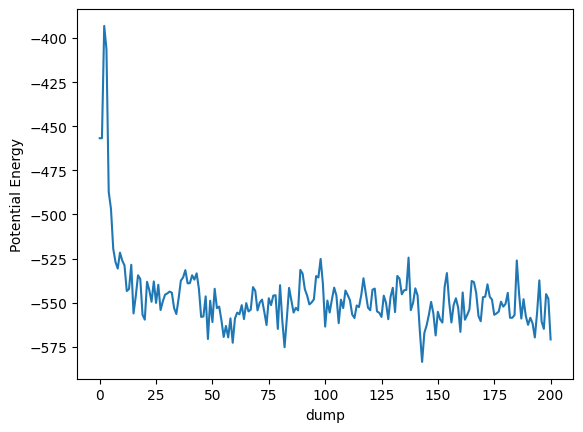

In [11]:
filename = "output_mc.dump"
num_particles = 108
rho = 0.8  # Example density, can be adjusted as needed
L = (num_particles / rho) ** (1/3)  # Calculate box length  
T = 1.0  # Temperature in reduced units
    
pos = initialize_positions(num_particles=num_particles, L=L)  # Example initialization
results = run(pos, L, num_steps=2000*num_particles, num_steps_between_dumps=10*num_particles, dr=0.2, T=T, r_c=2.5, filename=filename)

energies = results['energies']
plt.plot(energies)
plt.xlabel('dump')
plt.ylabel('Potential Energy')
plt.show()

### Ovito Python for post-processing

Ovito can be used for visualization and post-processing. For example, using the GUI the `modification` called `Coordination analysis` can be used to compute radial distribution functions of one frame in a simulation.
To get a high quality curve you would like to use `Time Averaging`. This is however not available in the non-payed basic version.
However, what is available is a Python interface. Below a implementation of a time-averaged radial distribution function using this Python interface is used.

### Post-processing: Radial Distribution Function (RDF)
This cell demonstrates how to use OVITO's Python interface to compute the radial distribution function (RDF) from the saved trajectory. The RDF provides insight into the structure of the simulated system and is a key analysis tool in molecular simulations.

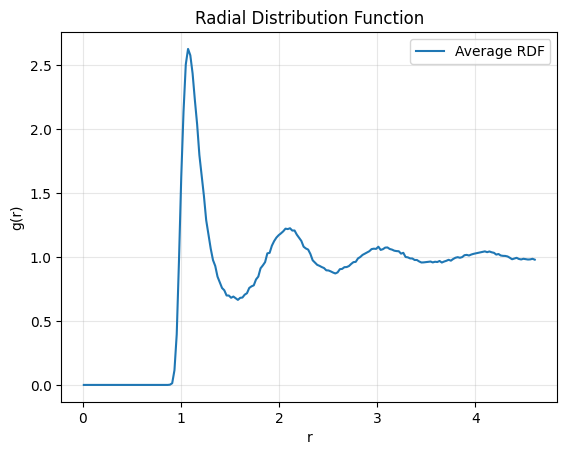

In [12]:
try:
    import ovito
except ImportError:
    install("ovito")

from ovito.io import import_file
from ovito.modifiers import CoordinationAnalysisModifier

# Load trajectory
def compute_rdf(filename, cutoff=10.0, number_of_bins=200, start_frame=0):
    """
    Compute the radial distribution function (RDF) from a trajectory file using OVITO.

    Args:
        filename (str): Path to the trajectory file (LAMMPS dump format).
        cutoff (float): Maximum distance for RDF calculation.
        number_of_bins (int): Number of bins for RDF histogram.
        start_frame (int): Frame index to start averaging RDF from.

    Returns:
        r (ndarray): Array of radial distances.
        rdf_avg (ndarray): Averaged RDF values over selected frames.
    """
    pipeline = import_file(filename, multiple_frames=True)
    # Add RDF modifier
    rdf = CoordinationAnalysisModifier(
        cutoff=cutoff,       # set appropriate cutoff
        number_of_bins=number_of_bins
    )
    #rdf.compute_partial = False
    pipeline.modifiers.append(rdf)

    # Accumulate RDF over frames
    rdf_sum = None
    nframes = pipeline.source.num_frames

    for frame in range(start_frame, nframes):
        data = pipeline.compute(frame)
        table = data.tables['coordination-rdf']
        xy = table.xy()
        g_r = xy[:, 1]
        if rdf_sum is None:
            rdf_sum = np.zeros_like(g_r)
            r = xy[:, 0].copy()
        rdf_sum += g_r
        rdf_avg = rdf_sum / (nframes - start_frame)
    return r, rdf_avg

r, rdf_avg = compute_rdf(filename, cutoff=0.9*L, start_frame=25)
plt.plot(r, rdf_avg, label='Average RDF')
plt.xlabel('r')
plt.ylabel('g(r)')
plt.title('Radial Distribution Function')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()